In [5]:
!pip install gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.6 MB/s eta 0:00:00


In [7]:
import networkx as nx
import random
from gensim.models import Word2Vec

# [Node2Vec](https://arxiv.org/pdf/1607.00653)

¿Cómo mapeamos las relaciones entre datos a un *embedding space*? Se inspira bastante en Word2Vec, algoritmo que pasa palabras a un espacio de incrustación.

Se define el *contexto* de un nodo en base a los vecinos de ese nodo. ¿Como entendemos ese contexto? Con la *homofilia* (nodos se enlazan con otros similares) y con equivalencias estructurales (detecta el rool de un nodo; por ejemplo, en sociales podría ser un *influencer*, o un puente entre comunidades). Así obtenemos un contexto local y global de los nodos.

Se inspiran en los algoritmos DFS y BFS, los cuales puedes ver su funcionamiento en el diagrama debajo:

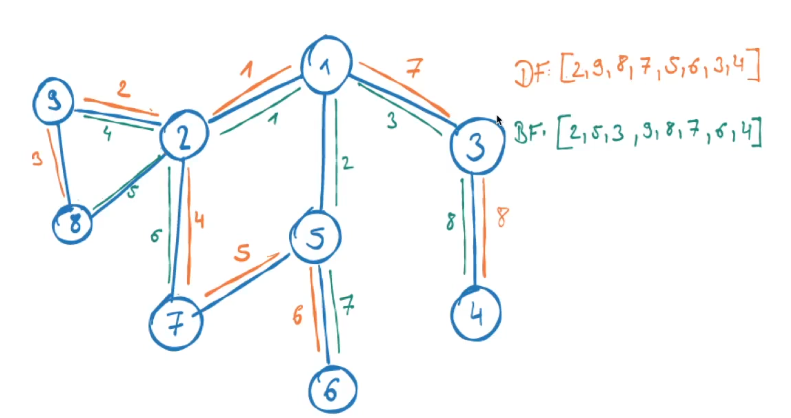

Supongamos que iniciamos en el nodo 1, calcularemos ambos algoritmos

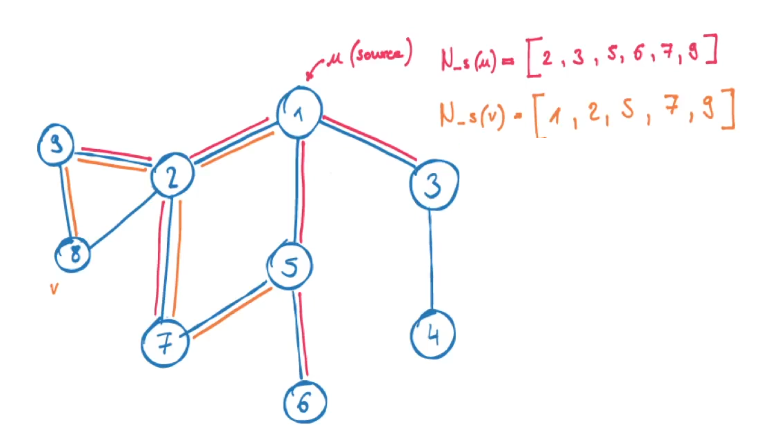

y usaremos la Similaridad de Jaccard

$J(A, B) = \frac{|A \cap B|}{|A \cup B| - |A \cap B|} = \frac{4}{6+5-4}$

para calcular el contexto del nodo.

Pero, ¿qué pasa con redes muy grandes que su anchura o profundidad nos llevaría a recorrerla toda, haciéndolo muy tardado? Bueno, para eso se hace un **muestreo aproximado** $S$ de caminatas aleatorias iniciando en cada nodo de la red.

A diferencia de Label propagation, aquí si hay *parámetros* que realizan un *tradeoff* entre BFS (homofilia) y DFS (equivalencia estructural).

En cada paso, la caminata aleatoria decide en base a los parámetros si se queda cerca del nodo inicial (homofilia) o si se mueve un nivel fuera (equivalencia estructural).

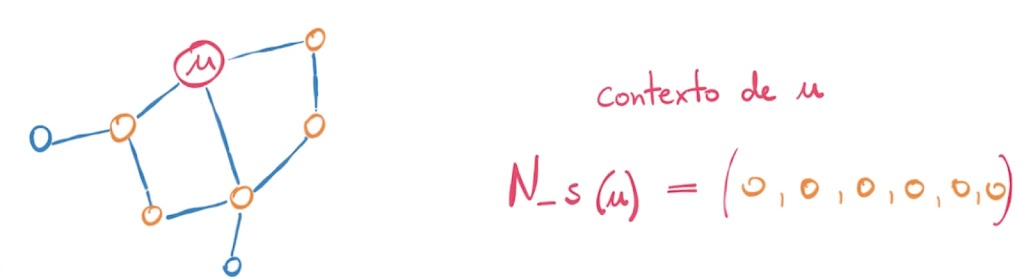

Ya con el contexto, queremos una representación tal que nodos con un contexto similar sean mapeados cerca en el *embedding space*.

¿Qué es cerca? Se mide con el producto punto de los vectores de 2 nodos, es simplemente el ángulo entre los vectores; entre menor sea, mas cerca están los nodos.

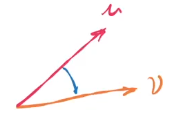

Transformamos ese *score* en probabilidades usando la función *softmax* (pues envía los valores entre 0 y 1)

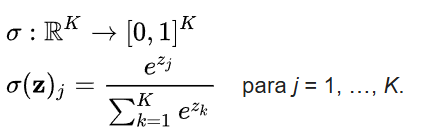

Lo que transforma a $f(u) * f(v)$ en una proba condicional $P(v|u)$, que podemos aplicar al contexto entero de u:


$P(N_s(u)|u)$, y si suponemos independencia, queda:

$\prod_{v_i \in N_s(u)} P(v_i|u)$

Y si lo hacemos en todos los contextos de todos los nodos a la vez nos queda la ecuación para realizar *graph embeddings*

$\sum_{u \in V} log P(N_s(u)|u)$, función la cual queremos **maximizar**, pues significaría que nodos cercanos tendrían una alta probabilidad de estar cerca en el *embedding space*

¿Cómo se maximiza? Con *Stochastic Gradient Decent*

[Lectura complementaria](https://medium.com/data-science/complete-guide-to-understanding-node2vec-algorithm-4e9a35e5d147)

In [8]:
#CAMINATA ALEATORIA SESGADA
def node2vec_walk(G, start_node, walk_length, p=1.0, q=1.0):
    """
    Genera UNA sola caminata aleatoria estilo Node2Vec desde un nodo inicial.
    """
    walk = [start_node]

    vecinos_iniciales = list(G.neighbors(start_node))
    if not vecinos_iniciales: # Si el nodo está aislado
        return walk

    siguiente_nodo = random.choice(vecinos_iniciales)
    walk.append(siguiente_nodo)

    #aplicamos la lógica de p y q (BFS vs DFS)
    for iteracion in range(1, walk_length - 1):
        prev_node = walk[-2]
        curr_node = walk[-1]
        vecinos_actuales = list(G.neighbors(curr_node))

        if not vecinos_actuales:
            break

        pesos_transicion = []

        for posible_siguiente in vecinos_actuales:
            if posible_siguiente == prev_node:
                pesos_transicion.append(1.0 / p)
            elif G.has_edge(prev_node, posible_siguiente):
                pesos_transicion.append(1.0)
            else:
                pesos_transicion.append(1.0 / q)

        siguiente_elegido = random.choices(vecinos_actuales, weights=pesos_transicion, k=1)[0]
        walk.append(siguiente_elegido)

    return walk

In [9]:
#FUNCIÓN PARA GENERAR EL CORPUS
def generar_caminatas(G, num_walks=10, walk_length=20, p=1.0, q=1.0):
    """
    Genera múltiples caminatas para TODOS los nodos del grafo.
    """
    todas_las_caminatas = []
    nodos = list(G.nodes())

    for i in range(num_walks):
        # Mezclamos los nodos en cada iteración para evitar sesgos
        random.shuffle(nodos)
        for nodo in nodos:
            caminata = node2vec_walk(G, nodo, walk_length, p, q)
            # Convertimos los IDs a strings (requerido si después usamos Gensim)
            todas_las_caminatas.append([str(n) for n in caminata])

    return todas_las_caminatas


In [17]:
G = nx.karate_club_graph()

#Parámetros: p bajo (promueve explorar), q alto (castiga ir lejos)
caminatas_bfs = generar_caminatas(G, num_walks=10, walk_length=12, p=0.5, q=2.0)

print(f"Se generaron {len(caminatas_bfs)} caminatas en total.")
print("Ejemplo de una caminata:")
print(caminatas_bfs[0])

Se generaron 340 caminatas en total.
Ejemplo de una caminata:
['16', '5', '0', '8', '30', '8', '32', '14', '32', '8', '32', '15']


In [18]:
modelo = Word2Vec(
    sentences=caminatas_bfs,
    vector_size=64, #Tamaño del embedding
    window=5,       #Tamaño de la ventana de contexto
    min_count=1,
    workers=4
)

print("Vector resultante para el nodo '0':")
print(modelo.wv['0'])

Vector resultante para el nodo '0':
[ 0.09562983 -0.09241588  0.45362923  0.24906747 -0.1111686  -0.28370866
  0.14825591  0.3493916  -0.19030893 -0.13504544  0.30340233 -0.12444244
  0.12199391  0.01101213 -0.10424954  0.06045287 -0.05596092  0.09239727
  0.00354136  0.1808343   0.22860613  0.20523216  0.49164042 -0.03648409
  0.02911488  0.328586   -0.19395292 -0.04143139 -0.0701014  -0.12191182
 -0.0498154   0.1149369  -0.52696055 -0.4520066   0.13781372  0.14022823
  0.20876846  0.2584593   0.51115173 -0.04116425  0.15717572  0.1733611
  0.03046644 -0.27936423  0.03985942 -0.15230192 -0.06142753 -0.21379262
 -0.02248237  0.21168858  0.23809667  0.02682714  0.02396121  0.3818236
  0.42389327  0.21238826  0.2096629  -0.30275592 -0.07424346 -0.12268697
  0.20840953 -0.22261193 -0.10762655  0.11975399]
